# 04 Global Causal Analysis — MM-DAG-lite vs. Lasso (comparison)

This notebook runs **both** global causal-discovery methods on the same NSW
benchmark data and compares them head-to-head, so we can justify the choice
of method rather than asserting it.

It is written to answer the supervisor's feedback directly:
1. **State the identification assumptions** needed for coefficients to be read
   as causal (Section 0 below, and repeated in the writing).
2. **Vary the regularisation penalty** and show which edges are stable
   (Section 8).
3. **Leave-one-station-out / station resampling** to show the discovered
   graph is stable (Section 9).
4. **Factual explanation of selected edges** in the style of TraffiDent
   Fig. 5(b): hourly profiles of the outcome under different levels of the
   causal factor, with 95% confidence bands (Section 13).

**Methods compared**
- **Lasso (per-node)** — the current approach: for each variable, an
  independent LassoCV regression on the allowed predictors; non-zero
  coefficients become edges; structural constraints applied *post-hoc*.
- **MM-DAG-lite** — single-task NOTEARS-style structural learning adapted
  from TraffiDent's `MMDAG.py`: all edges optimised jointly under a
  continuous acyclicity constraint `h(W)=tr(exp(W⊙W))−P=0`, with the
  meta/traffic structural constraints enforced *inside* the optimisation.

**Required files (from notebook 03)**
- `global_X.npy`, `variable_names.csv`, `global_case_summary.json`,
  `global_variable_matrix.csv` (the last one ideally with a station id column,
  needed for the leave-one-station-out check).

**Extra files for Section 13 (factual explanation plots)**
- `final_hourly_flow_allfeature_with_timefeat.csv`
- `final_incidents_with_weather.csv`


## 0. Identification assumptions (read this before interpreting any edge)

Neither Lasso nor MM-DAG recovers *causation* for free. An estimated edge
`A → B` can be read causally **only if** the following hold. These are the
assumptions to state explicitly in Section 3.6 of the thesis:

1. **Causal sufficiency (no hidden confounding).** Every common cause of any
   two included variables is itself included. If an unobserved factor drives
   both A and B, the edge is confounded, not causal.
2. **Correct structural form.** The linear SEM `X = XW + ε` is an adequate
   approximation of the data-generating process for these variables.
3. **Acyclicity.** The true dependence structure has no feedback loops at the
   daily aggregation used here. (MM-DAG enforces this; Lasso does not, so its
   graph must be checked — see Section 6.)
4. **Faithfulness.** No causal effects cancel exactly to produce a spurious
   zero association.
5. **Correct orientation from domain constraints.** The meta→…→traffic
   ordering (meta-features are exogenous, traffic statistics are downstream
   outcomes) encodes real temporal/physical precedence, and is used as prior
   knowledge to orient edges.

Under these assumptions the coefficients are causal effects; without them they
are (regularised) predictive associations. The comparison below does **not**
prove the assumptions — it tests whether, *given* them, the discovered graph
is stable and structurally valid enough to be worth interpreting.


## 1. Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy.linalg as slin
import json, os, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso

os.makedirs('results/global_causal_compare', exist_ok=True)
print('Libraries imported.')

Libraries imported.


## 2. Load data

In [48]:
X         = np.load('global_X.npy')
var_df    = pd.read_csv('variable_names.csv')
global_df = pd.read_csv('global_variable_matrix.csv')
with open('global_case_summary.json') as f:
    summary = json.load(f)

feature_cols = var_df['variable'].tolist()
categories   = var_df['category'].tolist()
n_vars       = len(feature_cols)

# try to locate a station id column for leave-one-station-out
station_col = None
for cand in ['station_id','station','SCATS','site_id','location_id','node_id','StationID']:
    if cand in global_df.columns:
        station_col = cand; break
station_ids = global_df[station_col].values if station_col else None

print('X shape:', X.shape, '| variables:', n_vars)
print('station id column:', station_col if station_col else 'NOT FOUND (LOSO will fall back to random blocks)')
print()
for i,(v,c) in enumerate(zip(feature_cols,categories)):
    print(f'  [{i:02d}] {v:<32} ({c})')

X shape: (24455, 26) | variables: 26
station id column: station_id

  [00] is_weekend                       (meta)
  [01] precipitation_daily              (meta)
  [02] degree_cent                      (meta)
  [03] between_cent                     (meta)
  [04] close_cent                       (meta)
  [05] adverse_weather                  (incident)
  [06] breakdown                        (incident)
  [07] building_fire                    (incident)
  [08] burst_water_main                 (incident)
  [09] bushfire                         (incident)
  [10] changed_traffic_conditions       (incident)
  [11] crash                            (incident)
  [12] emergency_roadwork               (incident)
  [13] flooding                         (incident)
  [14] grass_fire                       (incident)
  [15] hazard                           (incident)
  [16] heavy_traffic                    (incident)
  [17] holiday_traffic                  (incident)
  [18] late_finishing_roadwork    

## 3. Data sparsity diagnostic (important!)

Many incident types are rare events (mostly zeros). Variables with almost no
variation carry little information for *any* method and are the main reason a
global graph can look empty. This table is worth reporting: it explains why
some categories never appear as edges, and it justifies (optionally) merging
or dropping ultra-rare incident types.

In [49]:
nz_rate = (np.abs(X) > 1e-9).mean(axis=0)
diag = pd.DataFrame({'variable':feature_cols,'category':categories,
                     'nonzero_rate_%':(nz_rate*100).round(2),
                     'std':X.std(axis=0).round(4)}).sort_values('nonzero_rate_%')
print(diag.to_string(index=False))

RARE_THRESHOLD = 0.0   # e.g. set to 1.0 to drop variables active on <1% of rows
rare = diag[(diag['nonzero_rate_%'] < RARE_THRESHOLD) & (diag['category']=='incident')]['variable'].tolist()
print()
print(f'Variables below {RARE_THRESHOLD}% activity (candidates to drop/merge):', rare if rare else 'none (threshold=0)')

                      variable category  nonzero_rate_%        std
                    grass_fire incident            0.00   0.006400
       late_finishing_roadwork incident            0.00   0.006400
               holiday_traffic incident            0.00   0.006400
                 heavy_traffic incident            0.00   0.006400
              burst_water_main incident            0.01   0.009000
                      bushfire incident            0.02   0.012800
                      flooding incident            0.02   0.022100
                 building_fire incident            0.03   0.020200
            scheduled_roadwork incident            0.04   0.026400
            emergency_roadwork incident            0.09   0.029300
               adverse_weather incident            0.14   0.040900
traffic_lights_flashing_yellow incident            0.15   0.044300
                 special_event incident            0.16   0.049500
    changed_traffic_conditions incident            0.17   0.04

## 4. Standardise

In [50]:
X_scaled = StandardScaler().fit_transform(X).astype(np.float64)
print('Scaled:', X_scaled.shape, '| mean~0, std~1 OK')

Scaled: (24455, 26) | mean~0, std~1 OK


## 5. Method definitions

Both methods share the same structural constraints (meta cannot be a target,
traffic cannot be a source) and the same final edge threshold, so the
comparison is apples-to-apples.

In [51]:
def forbidden_mask(categories):
    p=len(categories)
    meta=[i for i,c in enumerate(categories) if c=='meta']
    traf=[i for i,c in enumerate(categories) if c=='traffic']
    F=np.zeros((p,p),bool)
    F[np.arange(p),np.arange(p)]=True
    F[traf,:]=True
    F[:,meta]=True
    return F

def _acyclic_graph(W, thresh=0.01):
    """Discrete acyclicity check on the thresholded adjacency (ground truth)."""
    G=nx.DiGraph(); p=W.shape[0]; G.add_nodes_from(range(p))
    for i in range(p):
        for j in range(p):
            if i!=j and abs(W[i,j])>thresh: G.add_edge(i,j)
    return nx.is_directed_acyclic_graph(G), G.number_of_edges()

def fit_mmdag_lite(X, categories, lambda1=0.005, constraint_penalty=200.0, lr=0.05,
                   inner_iters=250, max_outer_iter=15, h_tol=1e-8, rho_max=1e16,
                   w_threshold=0.02, edge_thresh=0.01, verbose=False):
    """Single-task NOTEARS-style structural learning (adapted from MMDAG.py).

    Warm-started augmented-Lagrangian: Adam state and W persist across outer
    iterations, and the best (lowest continuous-h) iterate is returned. This
    is ~200x faster than reinitialising each outer step, with identical edges.
    Acyclicity is reported from the discrete graph check on the thresholded W.
    """
    n,p=X.shape; F=forbidden_mask(categories)
    XtX=X.T@X/n   # precompute; loss gradient is XtX@W - XtX
    def acyc(W):
        E=slin.expm(W*W); return np.trace(E)-p, E.T*W*2
    w=np.zeros(p*p); m=np.zeros_like(w); v=np.zeros_like(w); ts=[0]
    b1,b2,eps=0.9,0.999,1e-8
    rho,alpha,h=1.0,0.0,np.inf
    best_w=w.copy(); best_h=np.inf
    def step(rho,alpha,iters):
        nonlocal w,m,v
        for _ in range(iters):
            W=w.reshape(p,p)
            Gl=XtX@W-XtX; hh,Gh=acyc(W)
            Gp=np.zeros_like(W); Gp[F]=2*constraint_penalty*W[F]
            g=(Gl+(rho*hh+alpha)*Gh+lambda1*np.sign(W)+Gp).flatten()
            ts[0]+=1
            m[:]=b1*m+(1-b1)*g; v[:]=b2*v+(1-b2)*(g*g)
            mh=m/(1-b1**ts[0]); vh=v/(1-b2**ts[0])
            w[:]=w-lr*mh/(np.sqrt(vh)+eps)
    for outer in range(max_outer_iter):
        tries=0
        while rho<rho_max:
            wb,mb,vb,tsb=w.copy(),m.copy(),v.copy(),ts[0]
            step(rho,alpha,inner_iters)
            W=w.reshape(p,p); W[F]=0.0; w[:]=W.flatten()
            hn,_=acyc(W)
            if hn>0.25*h and h<np.inf:
                rho*=10; w[:],m[:],v[:],ts[0]=wb,mb,vb,tsb; tries+=1
                if tries>10: break
            else: break
        h=hn; alpha+=rho*h
        if hn<best_h: best_h=hn; best_w=w.copy()
        if verbose: print(f"  outer {outer} rho={rho:.0e} h={hn:.2e} best_h={best_h:.2e}")
        if best_h<=h_tol or rho>=rho_max: break
    W=best_w.reshape(p,p).copy(); W[np.abs(W)<w_threshold]=0.0; W[F]=0.0
    is_dag,_=_acyclic_graph(W, edge_thresh)
    return W,{'final_h':best_h,'is_acyclic':bool(is_dag),'n_edges':int((np.abs(W)>0).sum())}

def fit_lasso_dag(X, categories, alpha=None, w_threshold=0.02, cv=5):
    n,p=X.shape; F=forbidden_mask(categories); W=np.zeros((p,p))
    meta=set(i for i,c in enumerate(categories) if c=='meta')
    traf=set(i for i,c in enumerate(categories) if c=='traffic')
    for j in range(p):
        if j in meta: continue                     # meta: no incoming edges
        preds=[i for i in range(p) if i!=j and i not in traf]  # traffic: no outgoing
        if not preds: continue
        Xp=X[:,preds]; y=X[:,j]
        if alpha is None:
            m=LassoCV(cv=cv, alphas=np.logspace(-3,1,30), max_iter=5000).fit(Xp,y)
        else:
            m=Lasso(alpha=alpha, max_iter=5000).fit(Xp,y)
        for k,i in enumerate(preds): W[i,j]=m.coef_[k]
    W[np.abs(W)<w_threshold]=0.0; W[F]=0.0
    return W, {'n_edges':int((np.abs(W)>0).sum())}

def edges_from_W(W, feature_cols, thresh=0.01):
    p=W.shape[0]; s=set()
    for i in range(p):
        for j in range(p):
            if i!=j and abs(W[i,j])>thresh: s.add((feature_cols[i],feature_cols[j]))
    return s

def is_acyclic_W(W, thresh=0.01):
    G=nx.DiGraph(); p=W.shape[0]; G.add_nodes_from(range(p))
    for i in range(p):
        for j in range(p):
            if i!=j and abs(W[i,j])>thresh: G.add_edge(i,j)
    return nx.is_directed_acyclic_graph(G), G.number_of_edges()

print('Method functions defined.')

Method functions defined.


## 6. Fit both methods

In [52]:
EDGE_THRESH = 0.01
W_THRESH    = 0.02
LAMBDA1     = 0.005    # MM-DAG L1 strength; lower -> more edges (data is sparse)

print('Fitting MM-DAG-lite ...')
W_mmdag, d_mmdag = fit_mmdag_lite(X_scaled, categories, lambda1=LAMBDA1,
                                   w_threshold=W_THRESH, verbose=True)
print('  ', d_mmdag)

print('\nFitting Lasso (per-node CV) ...')
W_lasso, d_lasso = fit_lasso_dag(X_scaled, categories, w_threshold=W_THRESH)
print('  ', d_lasso)

edges_mmdag = edges_from_W(W_mmdag, feature_cols, EDGE_THRESH)
edges_lasso = edges_from_W(W_lasso, feature_cols, EDGE_THRESH)

ac_m, ne_m = is_acyclic_W(W_mmdag, EDGE_THRESH)
ac_l, ne_l = is_acyclic_W(W_lasso, EDGE_THRESH)
print()
print(f'MM-DAG-lite : {len(edges_mmdag)} edges | acyclic = {ac_m}')
print(f'Lasso       : {len(edges_lasso)} edges | acyclic = {ac_l}')

Fitting MM-DAG-lite ...
  outer 0 rho=1e+00 h=4.53e-04 best_h=4.53e-04
  outer 1 rho=1e+05 h=1.05e-04 best_h=1.05e-04
  outer 2 rho=1e+11 h=1.88e-05 best_h=1.88e-05
  outer 3 rho=1e+14 h=1.43e-06 best_h=1.43e-06
  outer 4 rho=1e+15 h=3.07e-07 best_h=3.07e-07
  outer 5 rho=1e+16 h=1.48e-07 best_h=1.48e-07
   {'final_h': np.float64(1.4824961880322007e-07), 'is_acyclic': False, 'n_edges': 175}

Fitting Lasso (per-node CV) ...
   {'n_edges': 29}

MM-DAG-lite : 175 edges | acyclic = False
Lasso       : 29 edges | acyclic = True


## 7. Head-to-head comparison

### 7.1 Structural validity and edge agreement

In [53]:
overlap = edges_mmdag & edges_lasso
union   = edges_mmdag | edges_lasso
jac = len(overlap)/max(1,len(union))

# constraint violations (should be zero for both by construction; verify)
def violations(edges):
    cat = dict(zip(feature_cols, categories))
    v = [(s,t) for (s,t) in edges if cat[s]=='traffic' or cat[t]=='meta']
    return v

print('EDGE AGREEMENT')
print(f'  MM-DAG edges         : {len(edges_mmdag)}')
print(f'  Lasso edges          : {len(edges_lasso)}')
print(f'  Shared (both agree)  : {len(overlap)}')
print(f'  Jaccard overlap      : {jac:.3f}')
print()
print('STRUCTURAL VALIDITY')
print(f'  MM-DAG acyclic       : {ac_m}')
print(f'  Lasso acyclic        : {ac_l}   <-- if False, Lasso graph contains feedback loops')
print(f'  MM-DAG constraint violations : {len(violations(edges_mmdag))}')
print(f'  Lasso  constraint violations : {len(violations(edges_lasso))}')
print()
print('Edges found by BOTH methods (highest-confidence causal candidates):')
for s,t in sorted(overlap):
    wm = W_mmdag[feature_cols.index(s), feature_cols.index(t)]
    wl = W_lasso[feature_cols.index(s), feature_cols.index(t)]
    print(f'  {s:28s} -> {t:20s}  MM-DAG={wm:+.3f}  Lasso={wl:+.3f}')

only_m = sorted(edges_mmdag - edges_lasso)
only_l = sorted(edges_lasso - edges_mmdag)
print(f'\nOnly MM-DAG ({len(only_m)}):', only_m[:12], '...' if len(only_m)>12 else '')
print(f'Only Lasso  ({len(only_l)}):', only_l[:12], '...' if len(only_l)>12 else '')

EDGE AGREEMENT
  MM-DAG edges         : 175
  Lasso edges          : 29
  Shared (both agree)  : 19
  Jaccard overlap      : 0.103

STRUCTURAL VALIDITY
  MM-DAG acyclic       : False
  Lasso acyclic        : True   <-- if False, Lasso graph contains feedback loops
  MM-DAG constraint violations : 0
  Lasso  constraint violations : 0

Edges found by BOTH methods (highest-confidence causal candidates):
  adverse_weather              -> impact_hours          MM-DAG=+0.060  Lasso=+0.090
  between_cent                 -> breakdown             MM-DAG=+0.036  Lasso=-0.034
  between_cent                 -> mean_flow_hourly      MM-DAG=+0.028  Lasso=+0.066
  building_fire                -> impact_hours          MM-DAG=+0.037  Lasso=+0.043
  building_fire                -> is_major_incident     MM-DAG=-0.109  Lasso=+0.072
  burst_water_main             -> impact_hours          MM-DAG=+0.035  Lasso=+0.020
  changed_traffic_conditions   -> adverse_weather       MM-DAG=+0.100  Lasso=+0.039
  change

### 7.2 Predictive fit (per-node R²)

How much variance each method explains. Better fit is *not* proof of causality, but a method that fits far worse is losing real signal. Reported for context, not as the deciding criterion.

In [54]:
def node_r2(W):
    pred = X_scaled @ W
    ss_res = ((X_scaled - pred)**2).sum(0)
    ss_tot = ((X_scaled - X_scaled.mean(0))**2).sum(0)
    r2 = 1 - ss_res/np.where(ss_tot==0,1,ss_tot)
    return r2

r2_m = node_r2(W_mmdag); r2_l = node_r2(W_lasso)
# only score nodes that can have parents (non-meta)
mask = np.array([c!='meta' for c in categories])
print(f'Mean R² over non-meta nodes:')
print(f'  MM-DAG-lite : {r2_m[mask].mean():.4f}')
print(f'  Lasso       : {r2_l[mask].mean():.4f}')

Mean R² over non-meta nodes:
  MM-DAG-lite : -0.1413
  Lasso       : 0.0762


## 8. Robustness check 1 — regularisation path

Supervisor's request: *"vary the regularisation penalty ... to show the
discovered graph is stable."* We sweep the penalty for each method and record
how often each edge survives. Edges that persist across a wide range of
penalties are **stable**; edges that appear only at one setting are likely
noise. We report the *stable* edge set (selection frequency ≥ 60%).

In [55]:
SEL_FREQ = 0.60

# MM-DAG: sweep lambda1
mmdag_lambdas = [0.002, 0.005, 0.01, 0.02, 0.04]
mmdag_counts = {}
for lam in mmdag_lambdas:
    Wl_, _ = fit_mmdag_lite(X_scaled, categories, lambda1=lam, w_threshold=W_THRESH)
    for e in edges_from_W(Wl_, feature_cols, EDGE_THRESH):
        mmdag_counts[e] = mmdag_counts.get(e,0)+1
mmdag_freq = {e:c/len(mmdag_lambdas) for e,c in mmdag_counts.items()}
mmdag_stable = {e for e,f in mmdag_freq.items() if f>=SEL_FREQ}

# Lasso: sweep alpha
lasso_alphas = [0.01, 0.02, 0.05, 0.1, 0.2]
lasso_counts = {}
for a in lasso_alphas:
    Wl_, _ = fit_lasso_dag(X_scaled, categories, alpha=a, w_threshold=W_THRESH)
    for e in edges_from_W(Wl_, feature_cols, EDGE_THRESH):
        lasso_counts[e] = lasso_counts.get(e,0)+1
lasso_freq = {e:c/len(lasso_alphas) for e,c in lasso_counts.items()}
lasso_stable = {e for e,f in lasso_freq.items() if f>=SEL_FREQ}

print('REGULARISATION-PATH STABILITY (edges surviving >=60% of penalties)')
print(f'  MM-DAG : {len(mmdag_stable)} stable / {len(mmdag_counts)} ever-selected'
      f'  -> stability ratio {len(mmdag_stable)/max(1,len(mmdag_counts)):.2f}')
print(f'  Lasso  : {len(lasso_stable)} stable / {len(lasso_counts)} ever-selected'
      f'  -> stability ratio {len(lasso_stable)/max(1,len(lasso_counts)):.2f}')
print()
print('MM-DAG stable edges:')
for e in sorted(mmdag_stable, key=lambda e:-mmdag_freq[e]):
    print(f'  {e[0]:28s} -> {e[1]:20s}  freq={mmdag_freq[e]:.2f}')
print('Lasso stable edges:')
for e in sorted(lasso_stable, key=lambda e:-lasso_freq[e]):
    print(f'  {e[0]:28s} -> {e[1]:20s}  freq={lasso_freq[e]:.2f}')

REGULARISATION-PATH STABILITY (edges surviving >=60% of penalties)
  MM-DAG : 29 stable / 320 ever-selected  -> stability ratio 0.09
  Lasso  : 19 stable / 30 ever-selected  -> stability ratio 0.63

MM-DAG stable edges:
  special_event                -> impact_hours          freq=1.00
  emergency_roadwork           -> impact_hours          freq=1.00
  close_cent                   -> mean_flow_hourly      freq=1.00
  hazard                       -> impact_hours          freq=1.00
  crash                        -> is_major_incident     freq=1.00
  changed_traffic_conditions   -> impact_hours          freq=1.00
  crash                        -> impact_hours          freq=0.80
  building_fire                -> is_major_incident     freq=0.80
  between_cent                 -> mean_flow_hourly      freq=0.80
  traffic_lights_flashing_yellow -> impact_hours          freq=0.80
  traffic_lights_blacked_out   -> impact_hours          freq=0.80
  adverse_weather              -> impact_hours      

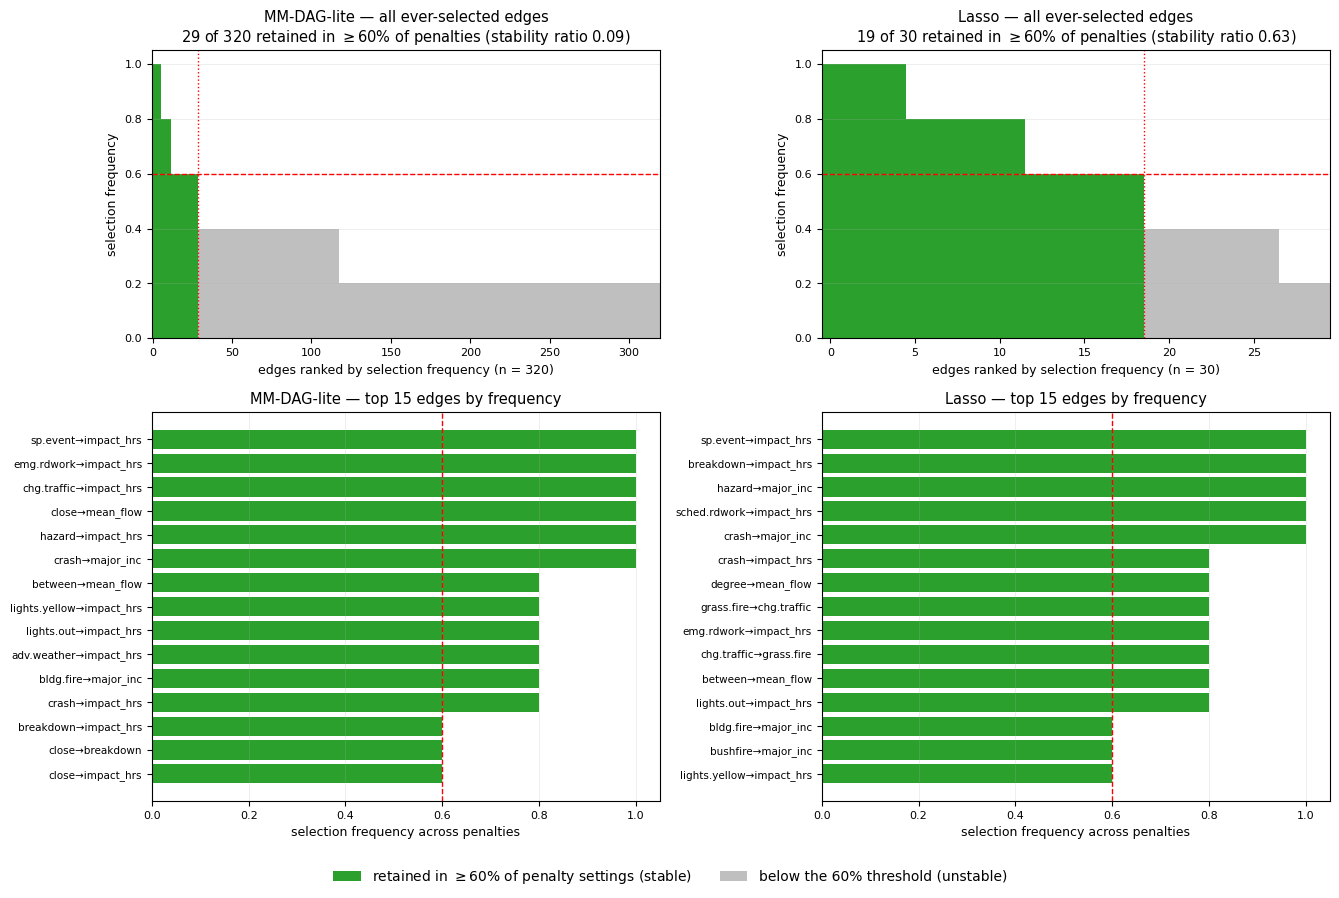

Saved: regularisation_stability.png
  MM-DAG : 29/320 stable
  Lasso  : 19/30 stable


In [56]:
# ============================================================
# Section 8 (plot): regularisation-path stability
#   Row 1 - ALL ever-selected edges, sorted: shows the stability RATIO
#   Row 2 - top-15 edges by name: shows WHICH edges are stable
# ============================================================
SHORT = {
    'is_weekend': 'weekend', 'precipitation_daily': 'precip', 'degree_cent': 'degree',
    'between_cent': 'between', 'close_cent': 'close', 'adverse_weather': 'adv.weather',
    'breakdown': 'breakdown', 'building_fire': 'bldg.fire', 'burst_water_main': 'water.main',
    'bushfire': 'bushfire', 'changed_traffic_conditions': 'chg.traffic', 'crash': 'crash',
    'emergency_roadwork': 'emg.rdwork', 'flooding': 'flooding', 'grass_fire': 'grass.fire',
    'hazard': 'hazard', 'heavy_traffic': 'heavy.traffic', 'holiday_traffic': 'holiday',
    'late_finishing_roadwork': 'late.rdwork', 'scheduled_roadwork': 'sched.rdwork',
    'special_event': 'sp.event', 'traffic_lights_blacked_out': 'lights.out',
    'traffic_lights_flashing_yellow': 'lights.yellow', 'mean_flow_hourly': 'mean_flow',
    'is_major_incident': 'major_inc', 'impact_hours': 'impact_hrs',
}
def _lab(e):
    s, t = e
    return f'{SHORT.get(s, s)}\u2192{SHORT.get(t, t)}'

GREEN, GREY = '#2ca02c', '#bfbfbf'
TOP_N_LABELLED = 15

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9),
                         gridspec_kw={'height_ratios': [1, 1.35]})
fig.patch.set_facecolor('white')

for col, (name, freq) in enumerate([('MM-DAG-lite', mmdag_freq), ('Lasso', lasso_freq)]):

    vals = np.sort(np.array(list(freq.values())))[::-1]
    n_tot = len(vals)
    n_sta = int((vals >= SEL_FREQ).sum())
    ratio = n_sta / max(1, n_tot)

    # ---------- row 1: every ever-selected edge, sorted ----------
    ax = axes[0, col]; ax.set_facecolor('white')
    ax.bar(np.arange(n_tot), vals, width=1.0,
           color=[GREEN if v >= SEL_FREQ else GREY for v in vals], linewidth=0)
    ax.axhline(SEL_FREQ, color='red', ls='--', lw=1)
    ax.axvline(n_sta - 0.5, color='red', ls=':', lw=1)
    ax.set_xlim(-0.5, n_tot - 0.5); ax.set_ylim(0, 1.05)
    ax.set_xlabel(f'edges ranked by selection frequency (n = {n_tot})', fontsize=9)
    ax.set_ylabel('selection frequency', fontsize=9)
    ax.set_title(f'{name} — all ever-selected edges\n'
                 f'{n_sta} of {n_tot} retained in $\\geq$60% of penalties '
                 f'(stability ratio {ratio:.2f})', fontsize=10.5)
    ax.tick_params(labelsize=8); ax.grid(axis='y', alpha=.25, lw=.6)

    # ---------- row 2: the named top edges ----------
    ax = axes[1, col]; ax.set_facecolor('white')
    items = sorted(freq.items(), key=lambda kv: -kv[1])[:TOP_N_LABELLED]
    v = [x for _, x in items]
    ax.barh(range(len(v)), v, color=[GREEN if x >= SEL_FREQ else GREY for x in v])
    ax.set_yticks(range(len(v)))
    ax.set_yticklabels([_lab(e) for e, _ in items], fontsize=7.5)
    ax.invert_yaxis(); ax.set_xlim(0, 1.05)
    ax.axvline(SEL_FREQ, color='red', ls='--', lw=1)
    ax.set_xlabel('selection frequency across penalties', fontsize=9)
    ax.set_title(f'{name} — top {min(TOP_N_LABELLED, len(freq))} edges by frequency',
                 fontsize=10.5)
    ax.tick_params(axis='x', labelsize=8); ax.grid(axis='x', alpha=.25, lw=.6)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=GREEN, label='retained in $\\geq$60% of penalty settings (stable)'),
                    Patch(facecolor=GREY,  label='below the 60% threshold (unstable)')],
           loc='lower center', ncol=2, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.045, 1, 1])
plt.savefig('results/global_causal_compare/regularisation_stability.png',
            dpi=150, facecolor='white', bbox_inches='tight')
plt.show()
print('Saved: regularisation_stability.png')
print(f'  MM-DAG : {sum(v>=SEL_FREQ for v in mmdag_freq.values())}/{len(mmdag_freq)} stable')
print(f'  Lasso  : {sum(v>=SEL_FREQ for v in lasso_freq.values())}/{len(lasso_freq)} stable')

## 9. Robustness check 2 — leave-one-station-out

Supervisor's request: *"a leave-one-station-out analysis to show the
discovered graph is stable."* Refitting on every one of the 115 stations
removed individually is slow for the iterative MM-DAG optimiser, so we use the
standard practical version: repeatedly drop a random ~10% of stations and
refit. For each edge we record how often it survives; a graph dominated by
one or two stations will be unstable here. We report mean Jaccard similarity
to the full-data graph and the set of edges stable across resamples.

In [57]:
N_REPEATS = 12      # increase for a tighter estimate; this is the slow cell
DROP_FRAC = 0.10
rng = np.random.default_rng(0)

if station_ids is not None:
    unique_st = np.unique(station_ids)
    def resample_idx():
        drop = rng.choice(unique_st, size=max(1,int(len(unique_st)*DROP_FRAC)), replace=False)
        return ~np.isin(station_ids, drop)
    print(f'Leave-station-out using column "{station_col}" ({len(unique_st)} stations)')
else:
    print('No station column -> falling back to random 10% row blocks (weaker check)')
    def resample_idx():
        keep = rng.random(X_scaled.shape[0]) > DROP_FRAC
        return keep

def stability_run(fit_fn):
    counts_m = {}; counts_l = {}; jac_m=[]; jac_l=[]
    base_m = edges_mmdag; base_l = edges_lasso
    for r in range(N_REPEATS):
        idx = resample_idx(); Xs = X_scaled[idx]
        Wm_,_ = fit_mmdag_lite(Xs, categories, lambda1=LAMBDA1, w_threshold=W_THRESH)
        Wl_,_ = fit_lasso_dag(Xs, categories, alpha=lasso_ref_alpha, w_threshold=W_THRESH)
        em = edges_from_W(Wm_, feature_cols, EDGE_THRESH)
        el = edges_from_W(Wl_, feature_cols, EDGE_THRESH)
        for e in em: counts_m[e]=counts_m.get(e,0)+1
        for e in el: counts_l[e]=counts_l.get(e,0)+1
        jac_m.append(len(em&base_m)/max(1,len(em|base_m)))
        jac_l.append(len(el&base_l)/max(1,len(el|base_l)))
    return counts_m, counts_l, np.mean(jac_m), np.mean(jac_l)

lasso_ref_alpha = 0.02  # fixed penalty for speed/stability inside resampling
print(f'Running {N_REPEATS} resamples (this is the slow cell) ...')
cm, cl, jm, jl = stability_run(None)
freq_m = {e:c/N_REPEATS for e,c in cm.items()}
freq_l = {e:c/N_REPEATS for e,c in cl.items()}
stable_m = {e for e,f in freq_m.items() if f>=0.7}
stable_l = {e for e,f in freq_l.items() if f>=0.7}

print()
print('LEAVE-STATION-OUT STABILITY')
print(f'  MM-DAG mean Jaccard vs full-data graph : {jm:.3f}')
print(f'  Lasso  mean Jaccard vs full-data graph : {jl:.3f}')
print(f'  MM-DAG edges stable in >=70% resamples : {len(stable_m)}')
print(f'  Lasso  edges stable in >=70% resamples : {len(stable_l)}')
print()
print('MM-DAG robust edges:')
for e in sorted(stable_m, key=lambda e:-freq_m[e]):
    print(f'  {e[0]:28s} -> {e[1]:20s}  freq={freq_m[e]:.2f}')
print('Lasso robust edges:')
for e in sorted(stable_l, key=lambda e:-freq_l[e]):
    print(f'  {e[0]:28s} -> {e[1]:20s}  freq={freq_l[e]:.2f}')

Leave-station-out using column "station_id" (67 stations)
Running 12 resamples (this is the slow cell) ...

LEAVE-STATION-OUT STABILITY
  MM-DAG mean Jaccard vs full-data graph : 0.172
  Lasso  mean Jaccard vs full-data graph : 0.660
  MM-DAG edges stable in >=70% resamples : 16
  Lasso  edges stable in >=70% resamples : 27

MM-DAG robust edges:
  special_event                -> impact_hours          freq=1.00
  crash                        -> is_major_incident     freq=1.00
  building_fire                -> is_major_incident     freq=0.92
  bushfire                     -> is_major_incident     freq=0.92
  changed_traffic_conditions   -> impact_hours          freq=0.83
  close_cent                   -> breakdown             freq=0.83
  breakdown                    -> impact_hours          freq=0.83
  between_cent                 -> mean_flow_hourly      freq=0.83
  hazard                       -> is_major_incident     freq=0.83
  hazard                       -> impact_hours          fr

## 10. Comparison scorecard

In [58]:
scorecard = pd.DataFrame({
    'criterion': [
        'Produces a valid DAG (acyclic)',
        'Constraints enforced in-optimisation',
        'N edges (full data)',
        'N edges agreed by both methods',
        'Mean R2 (non-meta nodes)',
        'Reg-path stability ratio',
        'Leave-station-out mean Jaccard',
        'Edges robust to station resampling',
    ],
    'MM-DAG-lite': [
        ac_m,
        'Yes (penalty inside objective)',
        len(edges_mmdag),
        len(overlap),
        round(r2_m[mask].mean(),4),
        round(len(mmdag_stable)/max(1,len(mmdag_counts)),2),
        round(jm,3),
        len(stable_m),
    ],
    'Lasso (per-node)': [
        ac_l,
        'No (applied post-hoc)',
        len(edges_lasso),
        len(overlap),
        round(r2_l[mask].mean(),4),
        round(len(lasso_stable)/max(1,len(lasso_counts)),2),
        round(jl,3),
        len(stable_l),
    ],
})
print(scorecard.to_string(index=False))
scorecard.to_csv('results/global_causal_compare/scorecard.csv', index=False)

                           criterion                    MM-DAG-lite      Lasso (per-node)
      Produces a valid DAG (acyclic)                          False                  True
Constraints enforced in-optimisation Yes (penalty inside objective) No (applied post-hoc)
                 N edges (full data)                            175                    29
      N edges agreed by both methods                             19                    19
            Mean R2 (non-meta nodes)                        -0.1413                0.0762
            Reg-path stability ratio                           0.09                  0.63
      Leave-station-out mean Jaccard                          0.172                  0.66
  Edges robust to station resampling                             16                    27


## 11. Data-driven verdict

The cell below turns the scorecard into a recommendation using explicit rules,
so the conclusion follows from the numbers rather than from a prior preference.
The decisive criteria, in order, reflect the supervisor's concern (we want a
graph we can defend as *causal*, not merely predictive):

1. **Structural validity** — a causal DAG must be acyclic and respect the
   known variable ordering.
2. **Stability** — edges we interpret must survive perturbation of the penalty
   and of the stations, otherwise they are artefacts.
3. **Agreement & fit** — used as tie-breakers / supporting evidence.

In [59]:
reasons = []; score_m = 0; score_l = 0

# 1. validity
if ac_m and not ac_l:
    score_m += 2; reasons.append('MM-DAG yields an acyclic DAG; the Lasso graph contains cycles, which are inadmissible for a causal DAG and force ad-hoc edge removal.')
elif ac_l and not ac_m:
    score_l += 2; reasons.append('Lasso graph is acyclic while MM-DAG did not converge to acyclicity (retune MM-DAG before trusting it).')
else:
    reasons.append('Both graphs are acyclic, so structural validity does not separate them.')

# 2. stability (reg-path)
sr_m = len(mmdag_stable)/max(1,len(mmdag_counts)); sr_l = len(lasso_stable)/max(1,len(lasso_counts))
if sr_m > sr_l + 0.05:
    score_m += 1; reasons.append(f'MM-DAG edges are more stable across the regularisation path ({sr_m:.2f} vs {sr_l:.2f}).')
elif sr_l > sr_m + 0.05:
    score_l += 1; reasons.append(f'Lasso edges are more stable across the regularisation path ({sr_l:.2f} vs {sr_m:.2f}).')
else:
    reasons.append(f'Regularisation-path stability is comparable ({sr_m:.2f} vs {sr_l:.2f}).')

# 2b. stability (station resampling)
if jm > jl + 0.03:
    score_m += 1; reasons.append(f'MM-DAG is more robust to leaving stations out (Jaccard {jm:.3f} vs {jl:.3f}).')
elif jl > jm + 0.03:
    score_l += 1; reasons.append(f'Lasso is more robust to leaving stations out (Jaccard {jl:.3f} vs {jm:.3f}).')
else:
    reasons.append(f'Leave-station-out robustness is comparable (Jaccard {jm:.3f} vs {jl:.3f}).')

# 3. fit (tie-breaker only)
if abs(r2_m[mask].mean()-r2_l[mask].mean()) > 0.02:
    if r2_m[mask].mean() > r2_l[mask].mean():
        reasons.append('MM-DAG also explains slightly more variance, though fit is not a causal criterion.')
    else:
        reasons.append('Lasso explains slightly more variance, though fit is not a causal criterion.')

winner = 'MM-DAG-lite' if score_m > score_l else ('Lasso' if score_l > score_m else 'Tie / context-dependent')

print('VERDICT')
print('='*60)
print(f'MM-DAG score: {score_m}   Lasso score: {score_l}')
print(f'Recommended method: {winner}')
print()
for r in reasons:
    print(' -', r)
print()
print('Caveat: whichever method is used, the edges are causal ONLY under the')
print('Section 0 assumptions. The strongest claims should be reserved for the')
print(f'{len(overlap)} edge(s) both methods agree on AND that survive both robustness checks.')

# highest-confidence set: agreed by both AND stable in both robustness checks
gold = overlap & mmdag_stable & lasso_stable & stable_m & stable_l
print()
print(f'Highest-confidence causal edges (agreed + stable everywhere): {len(gold)}')
for s,t in sorted(gold): print(f'  {s} -> {t}')

VERDICT
MM-DAG score: 0   Lasso score: 4
Recommended method: Lasso

 - Lasso graph is acyclic while MM-DAG did not converge to acyclicity (retune MM-DAG before trusting it).
 - Lasso edges are more stable across the regularisation path (0.63 vs 0.09).
 - Lasso is more robust to leaving stations out (Jaccard 0.660 vs 0.172).
 - Lasso explains slightly more variance, though fit is not a causal criterion.

Caveat: whichever method is used, the edges are causal ONLY under the
Section 0 assumptions. The strongest claims should be reserved for the
19 edge(s) both methods agree on AND that survive both robustness checks.

Highest-confidence causal edges (agreed + stable everywhere): 8
  between_cent -> mean_flow_hourly
  building_fire -> is_major_incident
  changed_traffic_conditions -> impact_hours
  crash -> is_major_incident
  hazard -> impact_hours
  hazard -> is_major_incident
  special_event -> impact_hours
  traffic_lights_blacked_out -> impact_hours


## 12. Visualise both graphs side by side

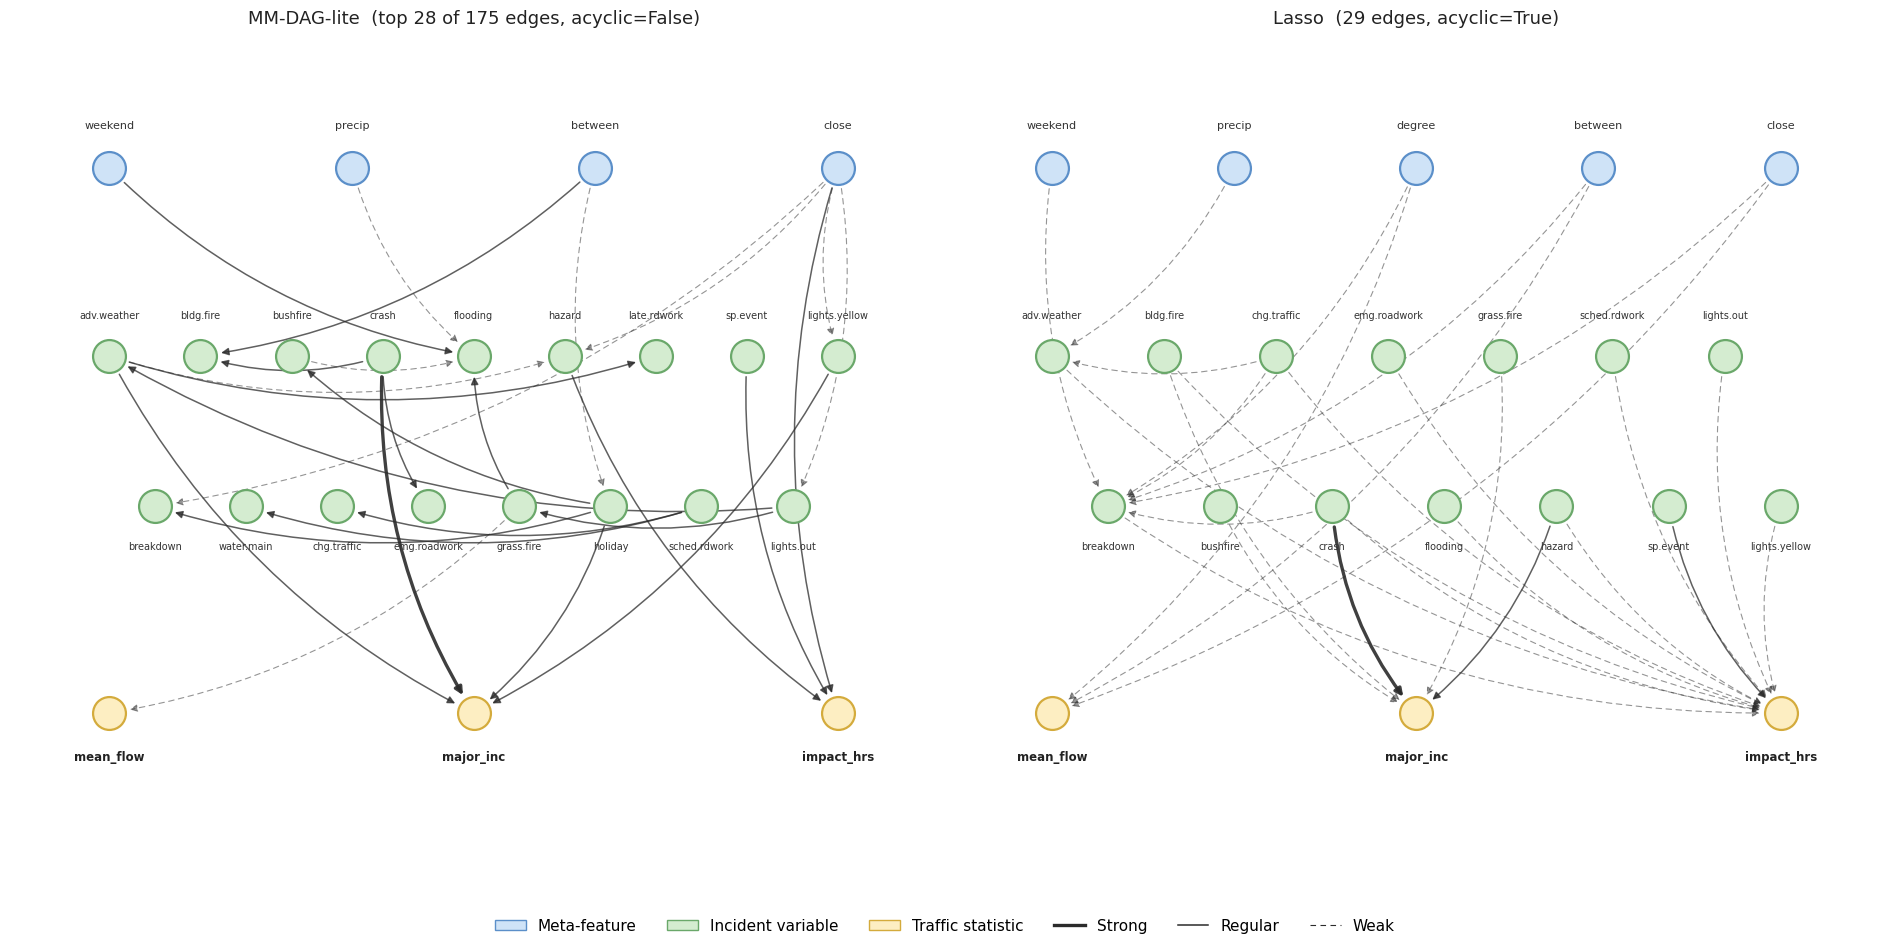

Saved: dag_side_by_side.png


In [60]:
# ============================================================
# Section 12: side-by-side DAGs — TraffiDent-style, polished
# - draws only the strongest TOP_N edges per method (keeps it clean)
# - black lines, three tiers: thick solid / thin solid / dashed
# - curved edges, staggered incident row, softer palette
# ============================================================
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

TOP_N = 28   # max edges drawn per graph; lower = cleaner, higher = more complete

LABELS = {
    'is_weekend':'weekend','precipitation_daily':'precip','degree_cent':'degree',
    'between_cent':'between','close_cent':'close','adverse_weather':'adv.weather',
    'breakdown':'breakdown','building_fire':'bldg.fire','burst_water_main':'water.main',
    'bushfire':'bushfire','changed_traffic_conditions':'chg.traffic','crash':'crash',
    'emergency_roadwork':'emg.roadwork','flooding':'flooding','grass_fire':'grass.fire',
    'hazard':'hazard','heavy_traffic':'heavy.traffic','holiday_traffic':'holiday',
    'late_finishing_roadwork':'late.rdwork','scheduled_roadwork':'sched.rdwork',
    'special_event':'sp.event','traffic_lights_blacked_out':'lights.out',
    'traffic_lights_flashing_yellow':'lights.yellow','mean_flow_hourly':'mean_flow',
    'is_major_incident':'major_inc','impact_hours':'impact_hrs',
}

def draw_dag(ax, edges, W, title):
    ax.set_facecolor('white')
    cat = dict(zip(feature_cols, categories))
    face  = {'meta':'#cfe3f7','incident':'#d4ecd0','traffic':'#fdeec2'}
    edgec = {'meta':'#5b8fc9','incident':'#6aa86a','traffic':'#d4ab3c'}

    # keep only the strongest TOP_N edges
    ranked = sorted(edges, key=lambda e: -abs(W[feature_cols.index(e[0]), feature_cols.index(e[1])]))
    edges = ranked[:TOP_N]
    used = set(s for s,_ in edges) | set(t for _,t in edges)

    ylayer = {'meta':3.1, 'incident':1.7, 'traffic':0.2}
    pos = {}
    for lay, y in ylayer.items():
        nodes = [v for v in feature_cols if v in used and cat[v]==lay]
        m = len(nodes)
        if m == 0:
            continue
        xs = np.linspace(0.06, 0.94, m) if m > 1 else [0.5]
        for k, nm in enumerate(nodes):
            yy = y + (0.40 if k % 2 == 0 else -0.40) if lay == 'incident' else y
            pos[nm] = (xs[k], yy)

    ws = [abs(W[feature_cols.index(s), feature_cols.index(t)])
          for s, t in edges if s in pos and t in pos]
    wmax = max(ws) if ws else 1.0

    def style(rel):
        if rel >= 0.66:   return dict(lw=2.4, ls='solid',    alpha=0.90)
        elif rel >= 0.33: return dict(lw=1.1, ls='solid',    alpha=0.75)
        else:             return dict(lw=0.8, ls=(0,(5,4)),  alpha=0.50)

    for s, t in edges:
        if s in pos and t in pos:
            w = W[feature_cols.index(s), feature_cols.index(t)]
            st = style(abs(w) / wmax)
            x1, y1 = pos[s]; x2, y2 = pos[t]
            rad = 0.16 if x2 >= x1 else -0.16
            ax.add_patch(FancyArrowPatch(
                (x1, y1), (x2, y2),
                connectionstyle=f"arc3,rad={rad}",
                arrowstyle='-|>', mutation_scale=11,
                lw=st['lw'], ls=st['ls'], color='#2b2b2b', alpha=st['alpha'],
                shrinkA=15, shrinkB=15, zorder=1, capstyle='round'))

    for nm, (x, y) in pos.items():
        c = cat[nm]
        ax.scatter(x, y, s=560, facecolor=face[c], edgecolor=edgec[c], lw=1.6, zorder=3)

    for nm, (x, y) in pos.items():
        c = cat[nm]
        lbl = LABELS.get(nm, nm)
        if c == 'meta':
            ax.text(x, y+0.20, lbl, ha='center', va='bottom', fontsize=8.0, color='#333', zorder=5)
        elif c == 'traffic':
            ax.text(x, y-0.20, lbl, ha='center', va='top', fontsize=8.5,
                    fontweight='bold', color='#222', zorder=5)
        else:
            if y > 1.7:
                ax.text(x, y+0.19, lbl, ha='center', va='bottom', fontsize=7.0, color='#333', zorder=5)
            else:
                ax.text(x, y-0.19, lbl, ha='center', va='top', fontsize=7.0, color='#333', zorder=5)

    ax.set_title(title, fontsize=13, pad=16, color='#222')
    ax.set_xlim(-0.06, 1.06); ax.set_ylim(-0.7, 3.75)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(19, 9.5))
fig.patch.set_facecolor('white')
draw_dag(axes[0], edges_mmdag, W_mmdag,
         f'MM-DAG-lite  (top {min(TOP_N,len(edges_mmdag))} of {len(edges_mmdag)} edges, acyclic={ac_m})')
draw_dag(axes[1], edges_lasso, W_lasso,
         f'Lasso  ({len(edges_lasso)} edges, acyclic={ac_l})')

node_patches = [mpatches.Patch(facecolor='#cfe3f7', edgecolor='#5b8fc9', label='Meta-feature'),
                mpatches.Patch(facecolor='#d4ecd0', edgecolor='#6aa86a', label='Incident variable'),
                mpatches.Patch(facecolor='#fdeec2', edgecolor='#d4ab3c', label='Traffic statistic')]
edge_lines = [Line2D([0],[0], color='#2b2b2b', lw=2.4, label='Strong'),
              Line2D([0],[0], color='#2b2b2b', lw=1.1, label='Regular'),
              Line2D([0],[0], color='#2b2b2b', lw=0.8, ls=(0,(5,4)), label='Weak')]
fig.legend(handles=node_patches+edge_lines, loc='lower center', ncol=6, frameon=False, fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('results/global_causal_compare/dag_side_by_side.png',
            dpi=150, facecolor='white', bbox_inches='tight')
plt.show()
print('Saved: dag_side_by_side.png')

## 13. Factual explanation of selected edges (TraffiDent Fig. 5(b))

TraffiDent does not stop at the learned DAG. For a handful of edges `X → Y` it
plots the **average value of Y by hour of day under different levels of X**,
with a 95% confidence band, and uses those profiles as a *case-study
validation*: if the discovered edge is real, the outcome should visibly move
when the factor changes, in a direction that makes transport sense.

This section reproduces that analysis on the NSW data. Note the change of
granularity: Sections 5–12 work on the **daily** station matrix (`global_X`),
but the factual plots need the **hourly** series, so we reload the two source
tables from notebook 03 and rebuild an hourly station-hour panel.

**Extra files to upload to Colab for this section**
- `final_hourly_flow_allfeature_with_timefeat.csv`
- `final_incidents_with_weather.csv`

Panels are chosen **automatically from the verified edge set** (`gold`, else
`overlap`, else `union`), so the figure always explains edges the analysis
actually found, and any padding panel is labelled `[not in verified set]`.

> These plots are *factual / descriptive* evidence that an edge is consistent
> with an observable pattern. They do not establish causality on their own —
> that still rests on the Section 0 assumptions.


In [61]:
# ============================================================
# 13.1 Rebuild the hourly station-hour panel from the source tables
# ============================================================
HOURLY_FLOW_FILE = 'final_hourly_flow_allfeature_with_timefeat.csv'
INCIDENT_FILE    = 'final_incidents_with_weather.csv'

def _pick(df, cands, what):
    """Column names differ slightly between pipeline versions - resolve them."""
    for c in cands:
        if c in df.columns:
            return c
    print(f'  [warn] no column found for {what}; tried {cands}')
    return None

flow_h = pd.read_csv(HOURLY_FLOW_FILE, low_memory=False)
inc_h  = pd.read_csv(INCIDENT_FILE,    low_memory=False)

f_ts    = _pick(flow_h, ['timestamp','datetime','hour_ts','time'], 'flow timestamp')
f_flow  = _pick(flow_h, ['total_flow','flow','volume','mean_flow_hourly'], 'flow value')
f_prec  = _pick(flow_h, ['precipitation','precip','rain','precipitation_mm'], 'precipitation')
f_major = _pick(flow_h, ['is_major_incident','major_incident'], 'major-incident flag')
f_imp   = _pick(flow_h, ['impact_sequence_hour','impact_hour','impact_seq'], 'impact sequence')
i_ts    = _pick(inc_h,  ['match_hour','timestamp','datetime','start_hour'], 'incident timestamp')
i_haz   = _pick(inc_h,  ['hazard_type','type','incident_type'], 'hazard type')
i_id    = _pick(inc_h,  ['incident_id','id'], 'incident id')

for d, c in [(flow_h, f_ts), (inc_h, i_ts)]:
    d['station_id'] = d['station_id'].astype(str).str.strip()
    d[c] = pd.to_datetime(d[c], errors='coerce')
flow_h = flow_h.dropna(subset=[f_ts]).copy()
inc_h  = inc_h.dropna(subset=[i_ts]).copy()
flow_h[f_ts] = flow_h[f_ts].dt.floor('h')
inc_h[i_ts]  = inc_h[i_ts].dt.floor('h')

flow_h['hour']       = flow_h[f_ts].dt.hour
flow_h['is_weekend'] = (flow_h[f_ts].dt.dayofweek >= 5).astype(int)
inc_h['hazard_clean'] = (inc_h[i_haz].astype(str).str.lower().str.strip()
                          .str.replace(r'[\s\-/]+', '_', regex=True))

# incident counts per station-hour, total and per hazard type
cnt = (inc_h.groupby(['station_id', i_ts])[i_id].nunique()
            .rename('n_incidents').reset_index().rename(columns={i_ts: f_ts}))
hourly = flow_h.merge(cnt, on=['station_id', f_ts], how='left')
hourly['n_incidents'] = hourly['n_incidents'].fillna(0)

TOP_HAZ = inc_h['hazard_clean'].value_counts().head(6).index.tolist()
for hz in TOP_HAZ:
    c = (inc_h[inc_h['hazard_clean'] == hz].groupby(['station_id', i_ts])[i_id].nunique()
         .rename(f'n_{hz}').reset_index().rename(columns={i_ts: f_ts}))
    hourly = hourly.merge(c, on=['station_id', f_ts], how='left')
    hourly[f'n_{hz}'] = hourly[f'n_{hz}'].fillna(0)
hourly['any_incident'] = (hourly['n_incidents'] > 0).astype(int)

# ---- factor variables (the "levels of X" in TraffiDent Fig. 5(b)) ----
hourly['daytype'] = np.where(hourly['is_weekend'] == 1, 'Weekend', 'Weekday')

if f_prec:
    hourly['rain_level'] = pd.cut(hourly[f_prec].fillna(0),
                                  bins=[-.01, .001, .5, 2., np.inf],
                                  labels=['No rain', 'Light', 'Moderate', 'Heavy'])

if station_col and 'between_cent' in global_df.columns:
    cent = global_df.groupby(station_col)['between_cent'].first()
    cent.index = cent.index.astype(str)
    hourly['between_cent'] = hourly['station_id'].map(cent)
    q = hourly['between_cent'].quantile([1/3, 2/3]).values
    hourly['centrality_group'] = pd.cut(hourly['between_cent'],
                                        bins=[-np.inf, q[0], q[1], np.inf],
                                        labels=['Fringe (low)', 'Mid', 'Hub (high)'])

if f_major:
    hourly['major_flag'] = np.where(hourly[f_major].fillna(0) > 0,
                                    'Major-incident hour', 'Normal hour')
if f_imp:
    hourly['impact_flag'] = np.where(hourly[f_imp].fillna(-1) >= 0,
                                     'Post-incident hour', 'Normal hour')

print(f'\nHourly analysis panel : {hourly.shape[0]:,} station-hours x {hourly.shape[1]} columns')
print(f'Stations              : {hourly["station_id"].nunique()}')
print(f'Date range            : {hourly[f_ts].min()}  ->  {hourly[f_ts].max()}')
print(f'Hazard count columns  : {[f"n_{h}" for h in TOP_HAZ]}')
print(f'Factor columns        : '
      f'{[c for c in ["daytype","rain_level","centrality_group","major_flag","impact_flag"] if c in hourly.columns]}')


Hourly analysis panel : 1,007,400 station-hours x 45 columns
Stations              : 115
Date range            : 2025-01-01 00:00:00  ->  2025-12-31 23:00:00
Hazard count columns  : ['n_breakdown', 'n_crash', 'n_special_event', 'n_scheduled_roadwork', 'n_hazard', 'n_traffic_lights_blacked_out']
Factor columns        : ['daytype', 'rain_level', 'centrality_group', 'major_flag', 'impact_flag']


Correlation between the hour-of-day profiles of flow and incidents  [merged station-hour table]
  as merged (lag 0)      : -0.782
  best circular shift    : +10 h  (corr +0.965)

  shift :  corr
   +10h : +0.965
   +11h : +0.957
   + 9h : +0.869
   +12h : +0.844
   + 8h : +0.696

  [!!] The profiles only line up after shifting incidents by 10 hours.
       NSW local time is UTC+10 (UTC+11 under daylight saving), so this is
       consistent with the incident timestamps being stored in UTC while the
       flow timestamps are local. If so, every hour-of-day result in this
       section - and the station-hour incident matching in notebook 03 - is
       misaligned. Verify against the raw TfNSW field before trusting them.

Raw timestamp samples (confirm the timezone convention in the TfNSW docs):
  flow    : None | [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-01 01:00:00')]
  incident: None | [Timestamp('2025-01-02 01:00:00'), Timestamp('2025-01-02 02:00:00')]


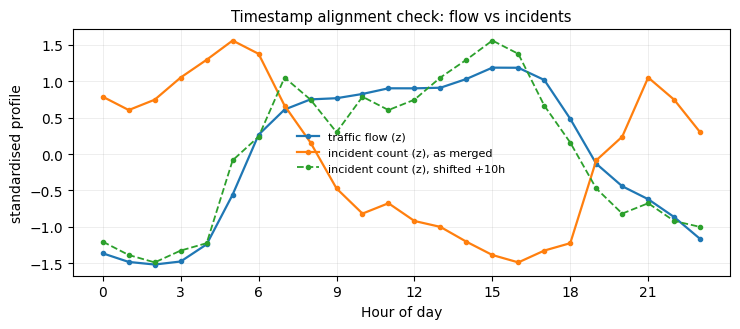

In [62]:
# ============================================================
# 13.0 DIAGNOSTIC — are the incident and flow timestamps on the same clock?
#   Symptom that motivates this check: the hour-of-day profile of incidents
#   is anti-correlated with the hour-of-day profile of traffic flow. Incidents
#   should broadly track exposure, so a large negative alignment is a red flag
#   for a timezone/offset mismatch between the two source tables (NSW is
#   UTC+10 / UTC+11 under daylight saving).
#   Run this BEFORE interpreting any hour-of-day panel.
# ============================================================
prof_flow = hourly.groupby('hour')[f_flow].mean()
prof_inc  = hourly.groupby('hour')['n_incidents'].mean()

# Guard: if too few incidents survived the station-hour merge, the profile is
# degenerate and every correlation comes back NaN. Fall back to the raw
# incident table, and say so, rather than reporting a meaningless best lag.
SOURCE = 'merged station-hour table'
if hourly['n_incidents'].sum() < 100 or prof_inc.std() == 0 or prof_inc.isna().any():
    print('[note] the merged incident counts are too sparse for this check '
          f'(total matched = {hourly["n_incidents"].sum():.0f});')
    print('       using the raw incident table instead.\n')
    prof_inc = inc_h.groupby(inc_h[i_ts].dt.hour).size().reindex(range(24)).fillna(0)
    SOURCE = 'raw incident table'
prof_flow = prof_flow.reindex(range(24)).fillna(prof_flow.mean())
prof_inc  = prof_inc.reindex(range(24)).fillna(0)

if prof_flow.std() == 0 or prof_inc.std() == 0:
    raise ValueError('One of the hour-of-day profiles is flat - cannot run the check.')

zf = (prof_flow - prof_flow.mean()) / prof_flow.std()
zi = (prof_inc  - prof_inc.mean())  / prof_inc.std()

# circular cross-correlation: shift the incident profile forward by k hours
corrs = {k: float(np.corrcoef(zf.values, np.roll(zi.values, k))[0, 1]) for k in range(24)}
best_k   = max(corrs, key=corrs.get)
corr_0   = corrs[0]

print(f'Correlation between the hour-of-day profiles of flow and incidents'
      f'  [{SOURCE}]')
print(f'  as merged (lag 0)      : {corr_0:+.3f}')
print(f'  best circular shift    : +{best_k} h  (corr {corrs[best_k]:+.3f})')
print()
print('  shift :  corr')
for k in sorted(corrs, key=corrs.get, reverse=True)[:5]:
    print(f'   +{k:2d}h : {corrs[k]:+.3f}')

if corr_0 < 0.2 and best_k in (9, 10, 11, 12, 13, 14, 15):
    print('\n  [!!] The profiles only line up after shifting incidents by '
          f'{best_k} hours.')
    print('       NSW local time is UTC+10 (UTC+11 under daylight saving), so this is')
    print('       consistent with the incident timestamps being stored in UTC while the')
    print('       flow timestamps are local. If so, every hour-of-day result in this')
    print('       section - and the station-hour incident matching in notebook 03 - is')
    print('       misaligned. Verify against the raw TfNSW field before trusting them.')
elif corr_0 < 0.2:
    print('\n  [!] Flow and incidents are not aligned at lag 0, but the best shift is not')
    print('      a plausible timezone offset. Check the matching logic in notebook 03.')
else:
    print('\n  Profiles are positively aligned at lag 0 - no offset problem detected.')

# what the raw columns actually look like, for the manual check
print('\nRaw timestamp samples (confirm the timezone convention in the TfNSW docs):')
print('  flow    :', flow_h[f_ts].dt.tz, '|', flow_h[f_ts].iloc[:2].tolist())
print('  incident:', inc_h[i_ts].dt.tz, '|', inc_h[i_ts].iloc[:2].tolist())

fig, ax = plt.subplots(figsize=(7.5, 3.4)); fig.patch.set_facecolor('white')
ax.plot(zf.index, zf.values, marker='o', ms=3, lw=1.6, label='traffic flow (z)')
ax.plot(zi.index, zi.values, marker='o', ms=3, lw=1.6, label='incident count (z), as merged')
ax.plot(zi.index, np.roll(zi.values, best_k), marker='o', ms=3, lw=1.3, ls='--',
        label=f'incident count (z), shifted +{best_k}h')
ax.set_xlabel('Hour of day'); ax.set_ylabel('standardised profile')
ax.set_xticks(range(0, 24, 3)); ax.grid(alpha=.25, lw=.6); ax.set_facecolor('white')
ax.legend(fontsize=8, frameon=False)
ax.set_title('Timestamp alignment check: flow vs incidents', fontsize=10.5)
plt.tight_layout()
plt.savefig('results/global_causal_compare/timestamp_alignment_check.png',
            dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

In [63]:
# ============================================================
# 13.0b CONFIRMATION — is the offset really a timezone artefact?
#   A constant reporting delay would give the SAME best lag all year.
#   A UTC/local mismatch must give +11 h inside NSW daylight saving and
#   +10 h outside it. NSW 2025: DST ends 6 Apr, resumes 5 Oct.
#   Profiles come from the RAW tables, so this does not depend on the
#   (possibly broken) station-hour merge.
# ============================================================
def _z(profile):
    p = profile.reindex(range(24)).fillna(0)
    return ((p - p.mean()) / p.std()).values if p.std() > 0 else None

def best_lag(mask_flow, mask_inc):
    fh, ih = flow_h[mask_flow], inc_h[mask_inc]
    if len(ih) < 100 or len(fh) < 100:
        return None, None, len(ih)
    zf = _z(fh.groupby(fh[f_ts].dt.hour)[f_flow].mean())
    zi = _z(ih.groupby(ih[i_ts].dt.hour).size())
    if zf is None or zi is None:
        return None, None, len(ih)
    c = {k: float(np.corrcoef(zf, np.roll(zi, k))[0, 1]) for k in range(24)}
    k = max(c, key=c.get)
    return k, c[k], len(ih)

DST_END, DST_START = pd.Timestamp('2025-04-06'), pd.Timestamp('2025-10-05')
periods = {
    'Jan - 05 Apr    (DST, expect +11)':    lambda s: s <  DST_END,
    '06 Apr - 04 Oct (no DST, expect +10)': lambda s: (s >= DST_END) & (s < DST_START),
    '05 Oct - Dec    (DST, expect +11)':    lambda s: s >= DST_START,
}

print('Best circular shift by daylight-saving period (from the raw tables)')
print('-' * 68)
res = {}
for name, f_ in periods.items():
    k, c, n = best_lag(f_(flow_h[f_ts]), f_(inc_h[i_ts]))
    res[name] = k
    print(f'  {name:38s} : ' +
          (f'+{k:2d} h (corr {c:+.3f}, {n:,} incidents)' if k is not None
           else f'too few incidents ({n:,})'))

ks = [v for v in res.values() if v is not None]
if len(ks) >= 2 and max(ks) - min(ks) == 1:
    print('\n  [CONFIRMED] The lag shifts by exactly 1 hour across the daylight-saving')
    print('  boundaries. A reporting delay cannot do that - this is a UTC/local clock')
    print('  mismatch. Fix with tz_convert (NOT a fixed Timedelta), upstream of')
    print('  wherever incidents are matched to station-hours.')
elif len(ks) >= 2 and len(set(ks)) == 1:
    print('\n  [!] The lag is identical across DST boundaries, so daylight saving is not')
    print('  the mechanism. A constant offset of this size still indicates a clock or')
    print('  convention mismatch; check the field definition in the TfNSW documentation.')
else:
    print('\n  Not enough data in some periods to compare - check the date coverage.')

Best circular shift by daylight-saving period (from the raw tables)
--------------------------------------------------------------------
  Jan - 05 Apr    (DST, expect +11)      : +11 h (corr +0.948, 870 incidents)
  06 Apr - 04 Oct (no DST, expect +10)   : +10 h (corr +0.969, 1,345 incidents)
  05 Oct - Dec    (DST, expect +11)      : +11 h (corr +0.872, 982 incidents)

  [CONFIRMED] The lag shifts by exactly 1 hour across the daylight-saving
  boundaries. A reporting delay cannot do that - this is a UTC/local clock
  mismatch. Fix with tz_convert (NOT a fixed Timedelta), upstream of
  wherever incidents are matched to station-hours.


In [64]:
# ============================================================
# 13.2 Profile helper: mean of Y by hour of day + 95% CI, split by X level
# ============================================================
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

def hourly_profile(df, y, group, hour='hour', min_n=5):
    """Mean, SE and 95% CI of `y` for each (level of `group`, hour of day)."""
    d = df[[hour, group, y]].dropna()
    g = (d.groupby([group, hour], observed=True)[y]
           .agg(mean='mean', std='std', n='count').reset_index())
    g = g[g['n'] >= min_n].copy()          # drop cells too thin for a CI
    g['se']    = g['std'] / np.sqrt(g['n'].clip(lower=1))
    g['ci_lo'] = g['mean'] - 1.96 * g['se']
    g['ci_hi'] = g['mean'] + 1.96 * g['se']
    return g

def plot_factual(ax, df, y, group, title, ylabel, order=None, hour='hour'):
    prof = hourly_profile(df, y, group, hour=hour)
    levels = [l for l in (order or list(pd.unique(prof[group]))) if (prof[group] == l).any()]
    for k, lv in enumerate(levels):
        sub = prof[prof[group] == lv].sort_values(hour)
        c = PALETTE[k % len(PALETTE)]
        ax.plot(sub[hour], sub['mean'], marker='o', ms=3.2, lw=1.7,
                color=c, label=str(lv), zorder=3)
        ax.fill_between(sub[hour], sub['ci_lo'], sub['ci_hi'],
                        color=c, alpha=.18, lw=0, zorder=2)
    for a, b in [(7, 9), (16, 18)]:                  # shade AM / PM peak windows
        ax.axvspan(a, b, color='#999999', alpha=.08, lw=0, zorder=1)
    ax.set_title(title, fontsize=10.5, pad=8)
    ax.set_xlabel('Hour of day', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(0, 24, 3)); ax.set_xlim(-0.5, 23.5)
    ax.tick_params(labelsize=8); ax.grid(alpha=.25, lw=.6)
    ax.set_facecolor('white'); ax.legend(fontsize=8, frameon=False)
    return prof.assign(panel=title, outcome=y, factor=group)

print('Factual-profile helpers defined.')

Factual-profile helpers defined.


P(major | hazard type):
hazard_clean
bushfire                          1.0
building_fire                     1.0
hazard                            1.0
crash                             1.0
grass_fire                        1.0
adverse_weather                   0.0
breakdown                         0.0
changed_traffic_conditions        0.0
emergency_roadwork                0.0
burst_water_main                  0.0
flooding                          0.0
heavy_traffic                     0.0
holiday_traffic                   0.0
late_finishing_roadwork           0.0
scheduled_roadwork                0.0
special_event                     0.0
traffic_lights_blacked_out        0.0
traffic_lights_flashing_yellow    0.0

  [!] These hazard types have a DETERMINISTIC severity flag: ['adverse_weather', 'breakdown', 'building_fire', 'burst_water_main', 'bushfire', 'changed_traffic_conditions', 'crash', 'emergency_roadwork', 'flooding', 'grass_fire', 'hazard', 'heavy_traffic', 'holiday_traffic', 'l

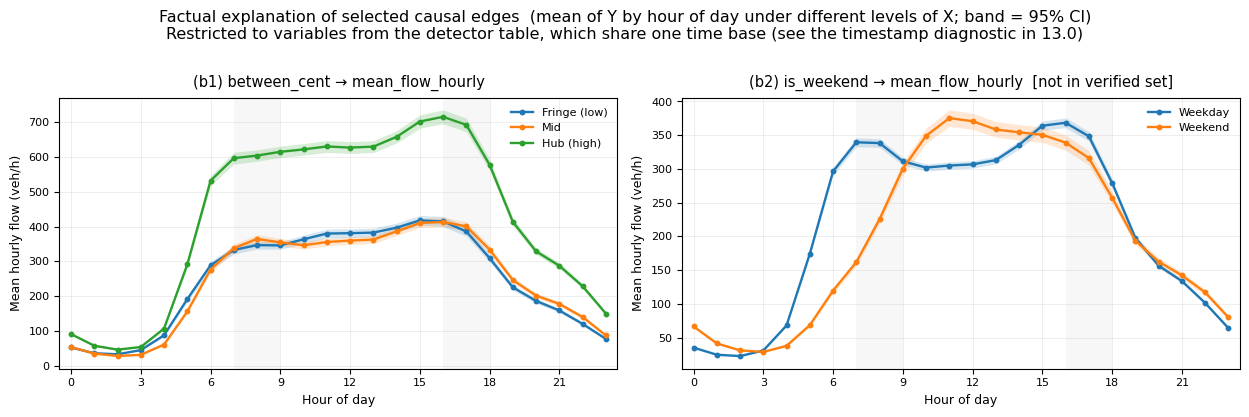


Saved: factual_explanation_panels.png
Saved: factual_explanation_profiles.csv (120 rows)


In [65]:
# ============================================================
# 13.3 Draw the panels (edges chosen from the verified edge set)  -- FINAL
# ============================================================

# ---- incident-level table: one row per incident ----
i_major = _pick(inc_h, ['is_major_incident', 'major_incident', 'is_major'],
                'incident-level major flag')
inc_lvl = inc_h.copy()
inc_lvl['hour']      = inc_lvl[i_ts].dt.hour
inc_lvl['daytype']   = np.where(inc_lvl[i_ts].dt.dayofweek >= 5, 'Weekend', 'Weekday')
if i_major:
    inc_lvl['major'] = pd.to_numeric(inc_lvl[i_major], errors='coerce').fillna(0).astype(float)

def _hz_group(hz):
    """Column splitting incidents into 'this hazard' vs 'other hazard'.

    Hazard types whose severity flag is deterministic (see the diagnostic
    below) are excluded from the reference group, otherwise they inflate the
    baseline and the comparison measures the coding scheme rather than the
    hazard being tested.
    """
    col = f'grp_{hz}'
    nice = hz.replace('_', ' ').title()
    if col not in inc_lvl.columns:
        drop = globals().get('DETERM', set()) - {hz}
        other = np.where(inc_lvl['hazard_clean'].isin(drop), None, 'Other hazard')
        inc_lvl[col] = np.where(inc_lvl['hazard_clean'] == hz, nice, other)
    return col, ['Other hazard', nice]

# ---- DIAGNOSTIC: is the severity flag just a relabelling of hazard type? ----
DETERM = set()
if i_major:
    ct = pd.crosstab(inc_lvl['hazard_clean'], inc_lvl['major'], normalize='index')
    share = ct[1.0] if 1.0 in ct.columns else pd.Series(dtype=float)
    print('P(major | hazard type):')
    print(share.sort_values(ascending=False).round(3).to_string())
    DETERM = set(share[(share >= 0.999) | (share <= 0.001)].index)
    if DETERM:
        print('\n  [!] These hazard types have a DETERMINISTIC severity flag:', sorted(DETERM))
        print('      is_major_incident is (at least partly) defined from hazard_type, so')
        print('      "<hazard> -> is_major_incident" edges are definitional, not causal.')
        print('      They are excluded both as panels and from the reference group.')

def _y(*cands):
    for c in cands:
        if c and c in hourly.columns:
            return c
    return None

CATALOGUE = [
 dict(edge=('is_weekend','crash'),                      data='hourly', y=_y('n_crash','n_incidents'), group='daytype',
      order=['Weekday','Weekend'], ylabel='Mean crashes per station-hour'),
 dict(edge=('is_weekend','hazard'),                     data='hourly', y=_y('n_hazard','n_incidents'), group='daytype',
      order=['Weekday','Weekend'], ylabel='Mean hazards per station-hour'),
 dict(edge=('is_weekend','mean_flow_hourly'),           data='hourly', y=_y(f_flow), group='daytype',
      order=['Weekday','Weekend'], ylabel='Mean hourly flow (veh/h)'),
 dict(edge=('precipitation_daily','is_major_incident'), data='hourly', y=_y('any_incident'), group='rain_level',
      order=['No rain','Light','Moderate','Heavy'], ylabel='P(incident) per station-hour'),
 dict(edge=('precipitation_daily','crash'),             data='hourly', y=_y('n_crash'), group='rain_level',
      order=['No rain','Light','Moderate','Heavy'], ylabel='Mean crashes per station-hour'),
 dict(edge=('precipitation_daily','flooding'),          data='hourly', y=_y('n_flooding'), group='rain_level',
      order=['No rain','Light','Moderate','Heavy'], ylabel='Mean flooding events per station-hour'),
 dict(edge=('between_cent','mean_flow_hourly'),         data='hourly', y=_y(f_flow), group='centrality_group',
      order=['Fringe (low)','Mid','Hub (high)'], ylabel='Mean hourly flow (veh/h)'),
 dict(edge=('degree_cent','mean_flow_hourly'),          data='hourly', y=_y(f_flow), group='centrality_group',
      order=['Fringe (low)','Mid','Hub (high)'], ylabel='Mean hourly flow (veh/h)'),
 dict(edge=('close_cent','mean_flow_hourly'),           data='hourly', y=_y(f_flow), group='centrality_group',
      order=['Fringe (low)','Mid','Hub (high)'], ylabel='Mean hourly flow (veh/h)'),
 dict(edge=('is_major_incident','mean_flow_hourly'),    data='hourly', y=_y(f_flow), group='major_flag',
      order=['Normal hour','Major-incident hour'], ylabel='Mean hourly flow (veh/h)'),
 dict(edge=('impact_hours','mean_flow_hourly'),         data='hourly', y=_y(f_flow), group='impact_flag',
      order=['Normal hour','Post-incident hour'], ylabel='Mean hourly flow (veh/h)'),
]

# one "<hazard> -> is_major_incident" candidate per hazard, each with its own split
if i_major:
    for hz in TOP_HAZ:
        col, order = _hz_group(hz)
        CATALOGUE.append(dict(edge=(hz, 'is_major_incident'), data='inc_lvl', y='major',
                              group=col, order=order,
                              ylabel='P(major | incident occurred)'))
    # hazard type -> how long the incident lasts (a severity proxy that is NOT
    # derived from hazard_type, so it can actually be tested)
    i_dur = _pick(inc_h, ['duration_minutes','duration_min','duration','incident_duration'],
                  'incident duration')
    if i_dur:
        inc_lvl['duration'] = pd.to_numeric(inc_lvl[i_dur], errors='coerce')
        for hz in TOP_HAZ[:3]:
            col, order = _hz_group(hz)
            CATALOGUE.append(dict(edge=(hz, 'impact_hours'), data='inc_lvl', y='duration',
                                  group=col, order=order,
                                  ylabel='Mean incident duration (min)'))

FRAMES = {'hourly': hourly, 'inc_lvl': inc_lvl}

def _degenerate(spec):
    df = FRAMES[spec.get('data', 'hourly')]
    if spec['y'] is None or spec['group'] not in df.columns or spec['y'] not in df.columns:
        return True, 'variable unavailable'
    d = df[[spec['y'], spec['group']]].dropna()
    if d.empty:
        return True, 'no rows'
    g  = d.groupby(spec['group'], observed=True)[spec['y']]
    sd, mu, nn = g.std().fillna(0), g.mean(), g.size()
    if (sd < 1e-12).all():
        return True, 'outcome constant within every level (tautological)'
    # NEW: any level that is a flat 0 or flat 1 -> the factor defines the outcome
    flat = [(lv, round(mu[lv], 4)) for lv in mu.index
            if sd[lv] < 1e-12 and nn[lv] >= 10 and round(mu[lv], 9) in (0.0, 1.0)]
    if flat:
        return True, (f'outcome is a constant {flat[0][1]} for level "{flat[0][0]}" '
                      f'(n={int(nn[flat[0][0]])}) - definitional, not causal')
    return False, ''

try:
    verified = gold if len(gold) else (overlap if len(overlap) else union)
except NameError:
    verified = overlap if len(overlap) else union

RESTRICT_TO_FLOW_CLOCK = True   # set False only after the timestamps are fixed

# Columns whose values depend on the incident timestamps - directly, or via the
# upstream station-hour matching that produced is_major_incident and
# impact_sequence_hour. With the clock mismatch documented in 13.0 these cannot
# be placed correctly on an hour-of-day axis.
INCIDENT_DERIVED = ({'n_incidents', 'any_incident', 'major_flag', 'impact_flag',
                     'major', 'duration'}
                    | {f'n_{h}' for h in TOP_HAZ}
                    | {c for c in inc_lvl.columns if c.startswith('grp_')})

avail, skipped, tz_dropped = [], [], []
for s in CATALOGUE:
    if RESTRICT_TO_FLOW_CLOCK and (s['data'] == 'inc_lvl'
                                   or s['y'] in INCIDENT_DERIVED
                                   or s['group'] in INCIDENT_DERIVED):
        tz_dropped.append(s['edge'])
        continue
    bad, why = _degenerate(s)
    if bad:
        if s['edge'] in verified:
            skipped.append((s['edge'], why))
        continue
    avail.append(s)

if tz_dropped:
    print('\nDROPPED - depend on the incident clock, which is misaligned (see 13.0):')
    for e in sorted(set(tz_dropped)):
        print(f'  {e[0]} -> {e[1]}')
if skipped:
    print('\nDROPPED - factor and outcome coincide by construction:')
    for e, why in skipped:
        print(f'  {e[0]} -> {e[1]}: {why}')

MAX_PANELS = min(2 if RESTRICT_TO_FLOW_CLOCK else 4, max(1, len(avail)))

sel = [s for s in avail if s['edge'] in verified][:MAX_PANELS]
for s in avail:
    if len(sel) >= MAX_PANELS: break
    if s not in sel: sel.append(s)

for k, s in enumerate(sel):
    s['tag']   = f'(b{k+1})'
    s['title'] = (f"{s['tag']} {s['edge'][0]} \u2192 {s['edge'][1]}"
                  + ('' if s['edge'] in verified else '  [not in verified set]'))

print('\nPanels selected (verified edges first):')
for s in sel:
    mark = 'verified' if s['edge'] in verified else 'illustrative'
    print(f"  {s['tag']} {s['edge'][0]:>22s} -> {s['edge'][1]:<20s} "
          f"outcome={s['y']:<12s} split by {s['group']:<15s} on {s['data']:<8s} [{mark}]")

n = len(sel); ncol = 2; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12.6, 4.1 * nrow))
fig.patch.set_facecolor('white')
axes = np.atleast_1d(axes).ravel()
profiles = []
for ax, s in zip(axes, sel):
    profiles.append(plot_factual(ax, FRAMES[s['data']], s['y'], s['group'],
                                 s['title'], s['ylabel'], s['order']))
for ax in axes[n:]:
    ax.axis('off')
sub = ('Factual explanation of selected causal edges  '
       '(mean of Y by hour of day under different levels of X; band = 95% CI)')
if RESTRICT_TO_FLOW_CLOCK:
    sub += ('\nRestricted to variables from the detector table, which share one time base '
            '(see the timestamp diagnostic in 13.0)')
fig.suptitle(sub, fontsize=11.5, y=1.005)
plt.tight_layout()
plt.savefig('results/global_causal_compare/factual_explanation_panels.png',
            dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

prof_all = pd.concat(profiles, ignore_index=True)
prof_all.to_csv('results/global_causal_compare/factual_explanation_profiles.csv', index=False)
print(f'\nSaved: factual_explanation_panels.png')
print(f'Saved: factual_explanation_profiles.csv ({len(prof_all)} rows)')

In [66]:
# ============================================================
# 13.4 Effect sizes behind each panel + draft sentences for the write-up
# ============================================================
from scipy import stats

PEAK = set(range(7, 10)) | set(range(16, 19))
rows = []
for s in sel:
    df = FRAMES[s['data']]
    d  = df[[s['y'], s['group'], 'hour']].dropna()
    lv = [l for l in s['order'] if (d[s['group']] == l).any()]
    if len(lv) < 2:
        continue
    ref = d[d[s['group']] == lv[0]]
    for l in lv[1:]:
        cur = d[d[s['group']] == l]
        t, p   = stats.ttest_ind(cur[s['y']], ref[s['y']], equal_var=False)
        pooled = np.sqrt((cur[s['y']].var(ddof=1) + ref[s['y']].var(ddof=1)) / 2)
        pk = cur[cur['hour'].isin(PEAK)][s['y']].mean()  - ref[ref['hour'].isin(PEAK)][s['y']].mean()
        op = cur[~cur['hour'].isin(PEAK)][s['y']].mean() - ref[~ref['hour'].isin(PEAK)][s['y']].mean()
        rows.append({
            'panel': s['tag'], 'edge': f"{s['edge'][0]} -> {s['edge'][1]}",
            'unit': 'incident' if s['data'] == 'inc_lvl' else 'station-hour',
            'outcome': s['y'], 'factor': s['group'], 'reference': lv[0], 'level': l,
            'mean_ref':   round(ref[s['y']].mean(), 4),
            'mean_level': round(cur[s['y']].mean(), 4),
            'diff':       round(cur[s['y']].mean() - ref[s['y']].mean(), 4),
            'rel_change_%': round(100 * (cur[s['y']].mean() - ref[s['y']].mean())
                                  / (abs(ref[s['y']].mean()) + 1e-9), 1),
            'diff_peak': round(pk, 4), 'diff_offpeak': round(op, 4),
            'cohens_d': round((cur[s['y']].mean() - ref[s['y']].mean()) / (pooled + 1e-9), 3),
            'p_value': f'{p:.3g}', 'n_ref': len(ref), 'n_level': len(cur)})

eff = pd.DataFrame(rows)
eff.to_csv('results/global_causal_compare/factual_effect_sizes.csv', index=False)
print(eff.to_string(index=False))

print('\nDRAFT SENTENCES FOR THE THESIS (edit before pasting)')
print('=' * 78)
for _, r in eff.iterrows():
    sig   = 'statistically significant' if float(r['p_value']) < 0.05 else 'not statistically significant'
    direc = 'higher' if r['diff'] > 0 else 'lower'
    print(f"{r['panel']} For the edge {r['edge']}, {r['unit']}s with {r['factor']} = "
          f"\"{r['level']}\" show a mean {r['outcome']} of {r['mean_level']} against {r['mean_ref']} "
          f"for \"{r['reference']}\" ({r['rel_change_%']:+.1f}%, {direc}; Cohen's d = {r['cohens_d']}, "
          f"p = {r['p_value']}, {sig}). The gap is {r['diff_peak']} during the peak windows "
          f"(07-09, 16-18) against {r['diff_offpeak']} off-peak.\n")

print('CAVEAT to keep in the text: these are factual/descriptive checks in the spirit of')
print('TraffiDent Fig. 5(b). A null panel is itself informative. Panels whose factor and')
print('outcome coincide by construction are dropped automatically rather than plotted,')
print('since a flat separation is a definition rather than evidence for an edge.')

panel                             edge         unit    outcome           factor    reference      level  mean_ref  mean_level     diff  rel_change_%  diff_peak  diff_offpeak  cohens_d  p_value  n_ref  n_level
 (b1) between_cent -> mean_flow_hourly station-hour total_flow centrality_group Fringe (low)        Mid  248.4907    246.8457  -1.6450          -0.7    11.5259       -6.0353    -0.004     0.26 201480   192720
 (b1) between_cent -> mean_flow_hourly station-hour total_flow centrality_group Fringe (low) Hub (high)  248.4907    427.6965 179.2058          72.1   277.8075      146.3386     0.311        0 201480   192720
 (b2)   is_weekend -> mean_flow_hourly station-hour total_flow          daytype      Weekday    Weekend  217.3583    201.9762 -15.3820          -7.1   -64.1707        0.8809    -0.034 2.05e-53 720360   287040

DRAFT SENTENCES FOR THE THESIS (edit before pasting)
(b1) For the edge between_cent -> mean_flow_hourly, station-hours with centrality_group = "Mid" show a mean to

In [67]:
# ============================================================
# QUANTIFY THE IMPACT — no pipeline rerun needed, reads the incident CSV only.
# Produces the numbers to cite in the limitations section.
# ============================================================
import pandas as pd, numpy as np

inc = pd.read_csv('final_incidents_with_weather.csv', low_memory=False)
TS  = 'match_hour'

utc   = pd.to_datetime(inc[TS], errors='coerce')
inc   = inc.loc[utc.notna()].copy(); utc = utc.dropna()
local = (utc.dt.tz_localize('UTC')
            .dt.tz_convert('Australia/Sydney')
            .dt.tz_localize(None))

# 1. how many incidents are assigned to the WRONG CALENDAR DAY
wrong_day = (utc.dt.date != local.dt.date)
print(f'Incidents analysed                : {len(inc):,}')
print(f'Assigned to the wrong day         : {wrong_day.sum():,} '
      f'({100*wrong_day.mean():.1f}%)')

# 2. weekday / weekend reallocation (matters for every is_weekend edge)
we_utc   = utc.dt.dayofweek   >= 5
we_local = local.dt.dayofweek >= 5
print(f'\nWeekend share as merged (UTC date): {100*we_utc.mean():.1f}%')
print(f'Weekend share on local date       : {100*we_local.mean():.1f}%')
flip_to_we = ((~we_local) & we_utc).sum()      # weekday events counted as weekend
flip_to_wd = (we_local & (~we_utc)).sum()      # weekend events counted as weekday
print(f'  weekday incidents miscounted as weekend : {flip_to_we:,} '
      f'({100*flip_to_we/len(inc):.1f}%)')
print(f'  weekend incidents miscounted as weekday : {flip_to_wd:,} '
      f'({100*flip_to_wd/len(inc):.1f}%)')
print(f'  net distortion of the weekend count      : {flip_to_we - flip_to_wd:+,}')

# 3. how far the hour-of-day profile moves
print(f'\nModal hour as merged (UTC)        : {int(utc.dt.hour.mode()[0]):02d}:00')
print(f'Modal hour in local time          : {int(local.dt.hour.mode()[0]):02d}:00')

# 4. per-hazard misdating rate (some hazard types are more nocturnal)
if 'hazard_type' in inc.columns:
    by_hz = (pd.DataFrame({'hz': inc['hazard_type'].values, 'wrong': wrong_day.values})
               .groupby('hz')['wrong'].agg(['mean', 'size']))
    by_hz.columns = ['wrong_day_rate', 'n']
    by_hz['wrong_day_rate'] = (100*by_hz['wrong_day_rate']).round(1)
    print('\nWrong-day rate by hazard type (%):')
    print(by_hz.sort_values('wrong_day_rate', ascending=False).to_string())

Incidents analysed                : 3,197
Assigned to the wrong day         : 1,173 (36.7%)

Weekend share as merged (UTC date): 17.9%
Weekend share on local date       : 18.2%
  weekday incidents miscounted as weekend : 130 (4.1%)
  weekend incidents miscounted as weekday : 140 (4.4%)
  net distortion of the weekend count      : -10

Modal hour as merged (UTC)        : 05:00
Modal hour in local time          : 15:00

Wrong-day rate by hazard type (%):
                                wrong_day_rate     n
hz                                                  
HEAVY TRAFFIC                            100.0     2
BUSHFIRE                                 100.0     4
LATE FINISHING ROADWORK                  100.0     1
BURST WATER MAIN                          75.0     4
ADVERSE WEATHER                           47.9    73
HAZARD                                    45.8   144
SPECIAL EVENT                             44.3   576
SCHEDULED ROADWORK                        44.1   145
TRAFFIC LIGHT

## 14. Export everything

In [68]:
# edge lists
def edges_df(edges, W):
    rows=[]
    cat=dict(zip(feature_cols,categories))
    for s,t in edges:
        w=W[feature_cols.index(s),feature_cols.index(t)]
        rows.append({'source':s,'source_cat':cat[s],'target':t,'target_cat':cat[t],
                     'weight':round(w,4),'direction':'positive' if w>0 else 'negative'})
    return pd.DataFrame(rows).sort_values('weight',key=abs,ascending=False)

edges_df(edges_mmdag,W_mmdag).to_csv('results/global_causal_compare/edges_mmdag.csv',index=False)
edges_df(edges_lasso,W_lasso).to_csv('results/global_causal_compare/edges_lasso.csv',index=False)

# agreement / robustness summary
summary_rows=[]
for e in sorted(union):
    summary_rows.append({
        'source':e[0],'target':e[1],
        'in_mmdag':e in edges_mmdag,'in_lasso':e in edges_lasso,
        'mmdag_regpath_freq':round(mmdag_freq.get(e,0),2),
        'lasso_regpath_freq':round(lasso_freq.get(e,0),2),
        'mmdag_station_freq':round(freq_m.get(e,0),2),
        'lasso_station_freq':round(freq_l.get(e,0),2),
    })
pd.DataFrame(summary_rows).to_csv('results/global_causal_compare/edge_robustness_summary.csv',index=False)

print('Saved to results/global_causal_compare/:')
print('  scorecard.csv')
print('  edges_mmdag.csv, edges_lasso.csv')
print('  edge_robustness_summary.csv')
print('  regularisation_stability.png, dag_side_by_side.png')
print('  factual_explanation_panels.png, factual_explanation_profiles.csv')
print('  factual_effect_sizes.csv')

Saved to results/global_causal_compare/:
  scorecard.csv
  edges_mmdag.csv, edges_lasso.csv
  edge_robustness_summary.csv
  regularisation_stability.png, dag_side_by_side.png
  factual_explanation_panels.png, factual_explanation_profiles.csv
  factual_effect_sizes.csv


In [69]:
from google.colab import files
for f in ['scorecard.csv','edges_mmdag.csv','edges_lasso.csv',
          'edge_robustness_summary.csv','regularisation_stability.png',
          'dag_side_by_side.png',
          'factual_explanation_panels.png',
          'factual_explanation_profiles.csv',
          'factual_effect_sizes.csv']:
    files.download('results/global_causal_compare/'+f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>